In [1]:
#CNN implementation here
#using the LOSO method, same as the random forest, so results are directly comparable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

In [4]:
#sliding window for CNN — returns raw sequences instead of statistical features
#window shape: (n_windows, window_size, n_features) so the CNN sees the full time series
def sliding_window_sequences(df, window_size=300, step=150):
    feature_cols = df.columns.drop("activityID")
    X, y = [], []

    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]

        label = window["activityID"].mode()[0]

        X.append(window[feature_cols].values)
        y.append(label)

    return np.array(X, dtype=np.float32), np.array(y)

In [5]:
import os
os.makedirs(r"/content/CPEN355_FinalProject/preprocessing/data", exist_ok=True)

for i in range(1, 9):
    globals()[f"data_{i}"] = pd.read_pickle(rf"/content/CPEN355_FinalProject/preprocessing/data/data_{i}.pkl")

X_all = {}
y_all = {}

for i in range(1, 9):
    df = globals()[f"data_{i}"]
    X, y = sliding_window_sequences(df, window_size=300, step=150)
    X_all[i] = X
    y_all[i] = y

#fit a single label encoder across all subjects so class indices are consistent
all_labels = np.concatenate(list(y_all.values()))
le = LabelEncoder()
le.fit(all_labels)
for i in range(1, 9):
    y_all[i] = le.transform(y_all[i])

In [6]:
# 1D CNN — Using Dropout1d (Spatial Dropout) to drop entire sensor channels
class PAMAP2_CNN(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=31, padding=15),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout1d(0.3),  # Spatial dropout

            nn.Conv1d(64, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout1d(0.3),  # Spatial dropout

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),    # Standard dropout is fine for Linear layers
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x))


#early stopping — stops when val loss hasn't improved for `patience` epochs
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience      = patience
        self.min_delta     = min_delta
        self.best_loss     = float('inf')
        self.best_weights  = None
        self.best_epoch    = 0
        self.counter       = 0
        self.stopped_epoch = 0

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.best_epoch   = epoch + 1
            self.counter      = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch + 1
                return True
        return False

    def restore(self, model):
        model.load_state_dict(self.best_weights)

In [7]:
# LOSO cross-validation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_FEATURES  = X_all[1].shape[2]
N_CLASSES   = len(le.classes_)
EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-4
PATIENCE    = 10

results = {}

# Track predictions across ALL subjects for the global confusion matrix
global_y_true = []
global_y_pred = []

for test_subject in range(1, 9):
    x_train = np.vstack([X_all[i] for i in range(1, 9) if i != test_subject])
    y_train = np.concatenate([y_all[i] for i in range(1, 9) if i != test_subject])
    x_test  = X_all[test_subject]
    y_test  = y_all[test_subject]

    n_train, W, F = x_train.shape
    n_test        = x_test.shape[0]
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train.reshape(-1, F)).reshape(n_train, W, F)
    x_test  = scaler.transform(x_test.reshape(-1, F)).reshape(n_test, W, F)

    x_train_t = torch.tensor(x_train.transpose(0, 2, 1))
    x_test_t  = torch.tensor(x_test.transpose(0, 2, 1))
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(x_test_t,  y_test_t),  batch_size=BATCH_SIZE)

    model      = PAMAP2_CNN(N_FEATURES, N_CLASSES).to(device)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
    
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stop = EarlyStopping(patience=PATIENCE)

    fold_train_losses = []
    fold_val_losses   = []

    for epoch in range(EPOCHS):
        # --- training ---
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            
            # 1. Noise + Random Amplitude Scaling
            noise = torch.randn_like(Xb) * 0.05
            scale = torch.empty(Xb.shape[0], 1, 1).uniform_(0.8, 1.2).to(device)
            Xb_aug = (Xb * scale) + noise

            # 2. NEW: Time Masking (Zero out a random 10% chunk of the time sequence)
            mask_len = int(Xb.shape[2] * 0.10) 
            start_idx = torch.randint(0, Xb.shape[2] - mask_len, (1,)).item()
            Xb_aug[:, :, start_idx:start_idx+mask_len] = 0.0

            optimizer.zero_grad()
            loss = criterion(model(Xb_aug), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        fold_train_losses.append(epoch_loss / n_batches)

        # --- validation ---
        model.eval()
        val_loss, n_val_batches = 0.0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss      += criterion(model(Xb), yb).item()
                n_val_batches += 1
        
        current_val_loss = val_loss / n_val_batches
        fold_val_losses.append(current_val_loss)

        scheduler.step(current_val_loss)

        if early_stop.step(fold_val_losses[-1], model, epoch):
            print(f"  Early stop at epoch {early_stop.stopped_epoch} "
                  f"(best weights from epoch {early_stop.best_epoch})")
            break

    early_stop.restore(model)

    model.eval()
    all_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            all_preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())

    global_y_true.extend(y_test)
    global_y_pred.extend(all_preds)

    acc = accuracy_score(y_test, all_preds)
    
    # NEW: Calculate per-subject F1 scores
    mac_f1 = f1_score(y_test, all_preds, average='macro')
    wt_f1  = f1_score(y_test, all_preds, average='weighted')

    results[test_subject] = {
        "accuracy":      acc,
        "macro_f1":      mac_f1,
        "weighted_f1":   wt_f1,
        "train_losses":  fold_train_losses,
        "val_losses":    fold_val_losses,
        "best_epoch":    early_stop.best_epoch,
    }

    print(f"Subject {test_subject} (test) — Accuracy: {acc:.4f} | Macro F1: {mac_f1:.4f}")

print(f"\nMean LOSO Accuracy: {np.mean([r['accuracy'] for r in results.values()]):.4f}")

  Early stop at epoch 34 (best weights from epoch 24)
Subject 1 (test) — Accuracy: 0.6796 | Macro F1: 0.6419


  Early stop at epoch 33 (best weights from epoch 23)
Subject 2 (test) — Accuracy: 0.6396 | Macro F1: 0.5537


  Early stop at epoch 73 (best weights from epoch 63)
Subject 3 (test) — Accuracy: 0.9808 | Macro F1: 0.9826


  Early stop at epoch 72 (best weights from epoch 62)
Subject 4 (test) — Accuracy: 0.9907 | Macro F1: 0.9917


  Early stop at epoch 69 (best weights from epoch 59)
Subject 5 (test) — Accuracy: 0.9375 | Macro F1: 0.9318


  Early stop at epoch 71 (best weights from epoch 61)
Subject 6 (test) — Accuracy: 0.9159 | Macro F1: 0.9242


  Early stop at epoch 76 (best weights from epoch 66)
Subject 7 (test) — Accuracy: 0.9717 | Macro F1: 0.9729


  Early stop at epoch 62 (best weights from epoch 52)
Subject 8 (test) — Accuracy: 0.7890 | Macro F1: 0.7778

Mean LOSO Accuracy: 0.8631


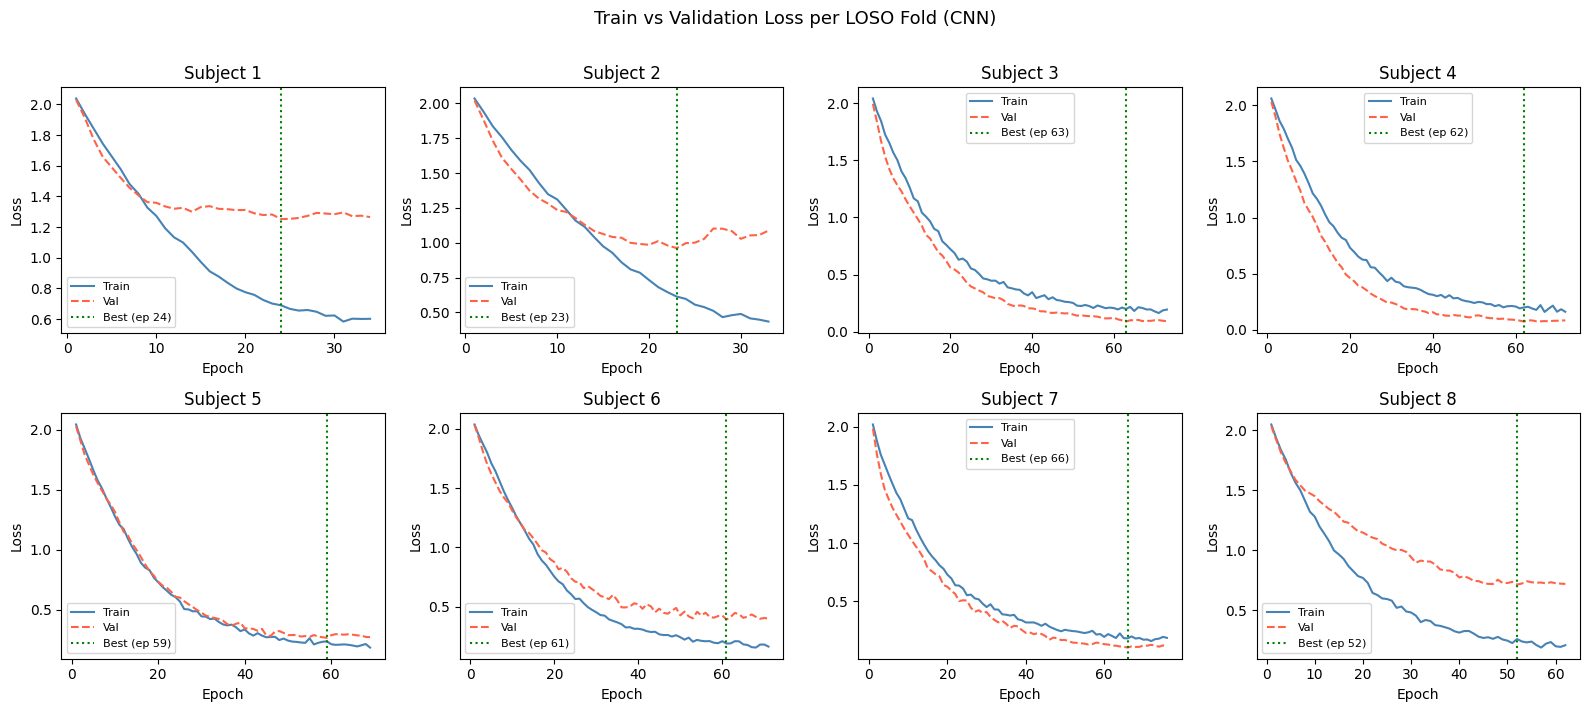

In [8]:
#training and validation loss curves — one subplot per subject
#green dotted line marks the epoch whose weights were restored for evaluation
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for idx, subject in enumerate(range(1, 9)):
    ax           = axes[idx]
    train_losses = results[subject]['train_losses']
    val_losses   = results[subject]['val_losses']
    best_epoch   = results[subject]['best_epoch']
    epochs_range = range(1, len(train_losses) + 1)

    ax.plot(epochs_range, train_losses, label='Train', color='steelblue')
    ax.plot(epochs_range, val_losses,   label='Val',   color='tomato', linestyle='--')
    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5,
               label=f'Best (ep {best_epoch})')   # where best weights came from
    ax.set_title(f'Subject {subject}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

plt.suptitle('Train vs Validation Loss per LOSO Fold (CNN)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('loso_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

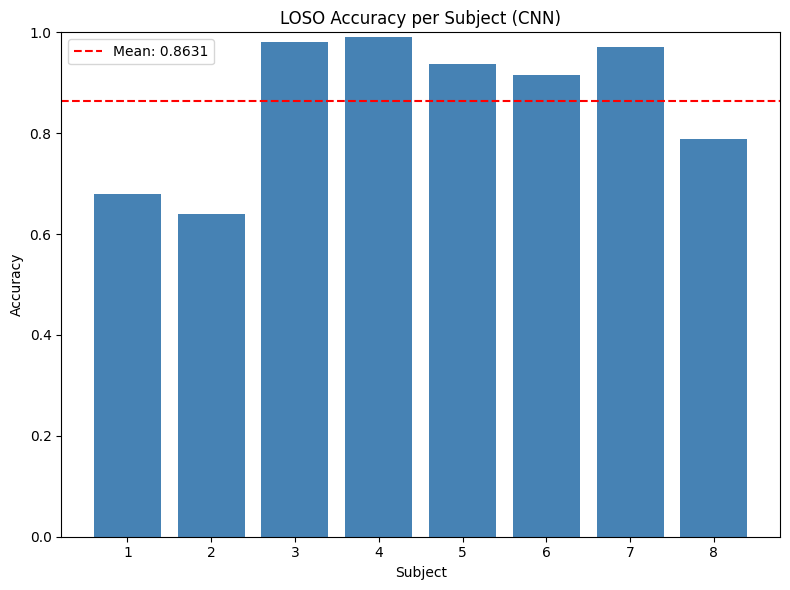

In [9]:
subjects = list(results.keys())
acc      = [results[s]['accuracy'] for s in subjects]

plt.figure(figsize=(8, 6))
plt.bar(subjects, acc, color='steelblue')
plt.axhline(y=np.mean(acc), color='red', linestyle='--', label=f'Mean: {np.mean(acc):.4f}')
plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.title('LOSO Accuracy per Subject (CNN)')
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_accuracy_cnn.png', dpi=150)
plt.show()

Global Macro F1-Score:    0.8683
Global Weighted F1-Score: 0.8634

              precision    recall  f1-score   support

           1       0.98      0.97      0.98       114
           2       0.87      0.74      0.80       111
           3       0.89      0.67      0.76       116
           4       0.99      0.98      0.99       133
          12       0.96      0.90      0.93        73
          13       0.95      0.87      0.91        63
          16       0.68      0.95      0.79       106
          17       0.75      0.82      0.78       144

    accuracy                           0.86       860
   macro avg       0.88      0.86      0.87       860
weighted avg       0.88      0.86      0.86       860



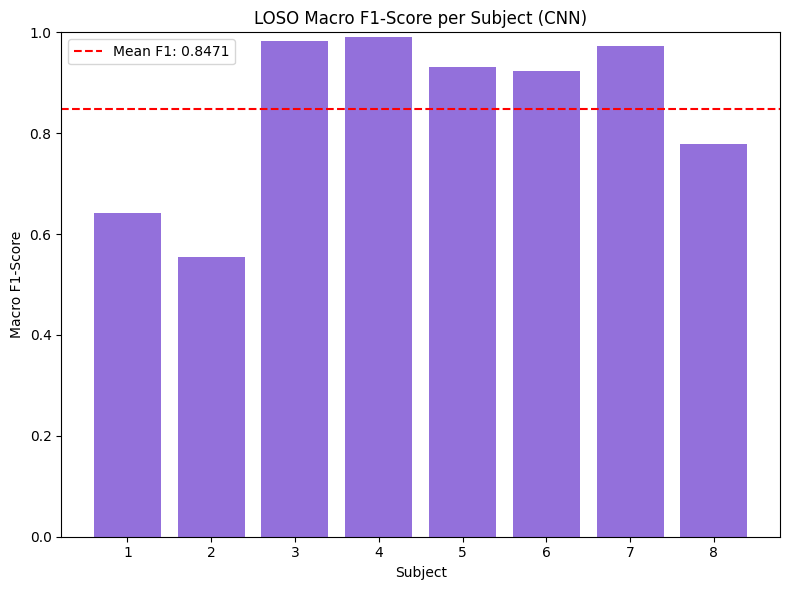

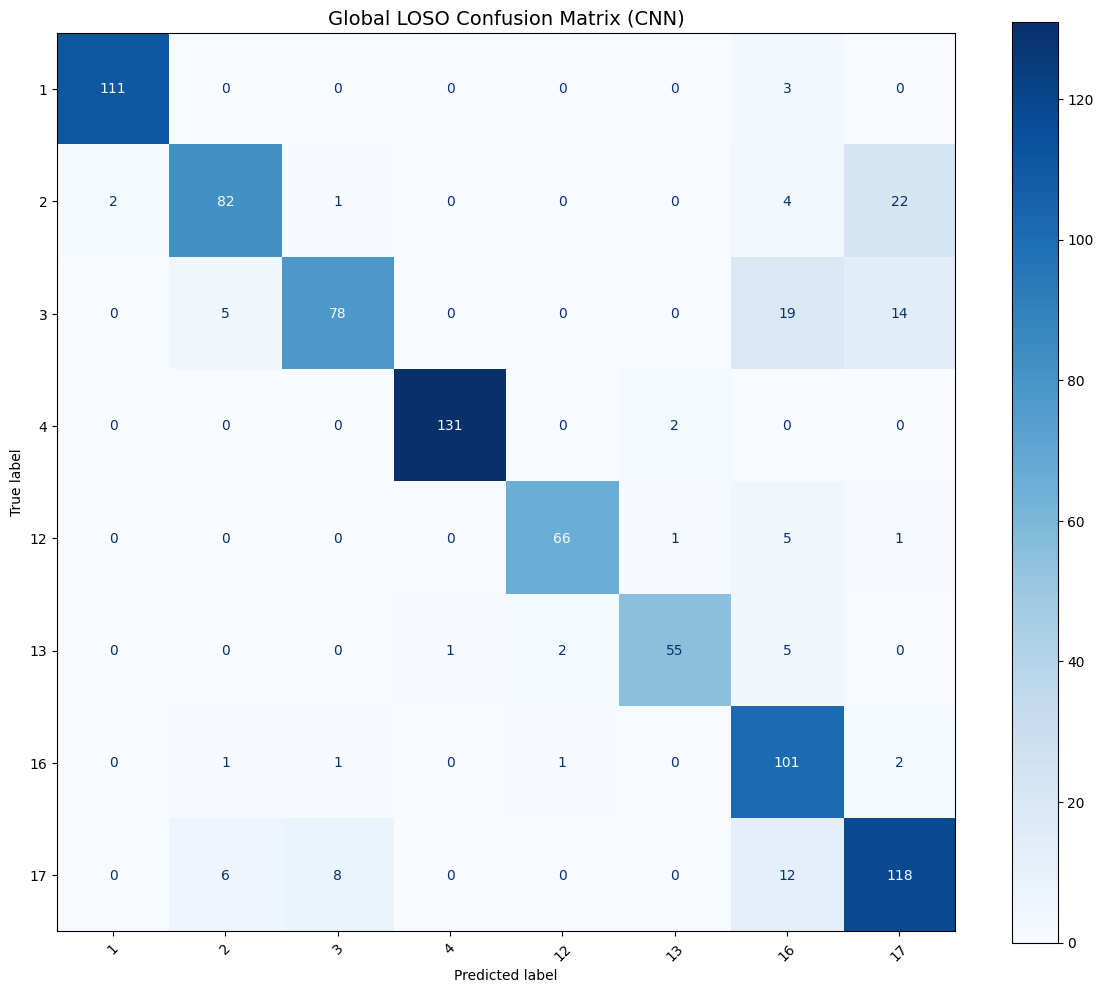

In [10]:
# --- Global Evaluation Metrics ---
# Calculate Macro F1 Score
macro_f1 = f1_score(global_y_true, global_y_pred, average='macro')
weighted_f1 = f1_score(global_y_true, global_y_pred, average='weighted')

print(f"Global Macro F1-Score:    {macro_f1:.4f}")
print(f"Global Weighted F1-Score: {weighted_f1:.4f}\n")

print(classification_report(global_y_true, global_y_pred, target_names=le.classes_.astype(str)))

# --- Plot the Macro F1 Score per subject ---
subjects  = list(results.keys())
macro_f1s = [results[s]['macro_f1'] for s in subjects]

plt.figure(figsize=(8, 6))
plt.bar(subjects, macro_f1s, color='mediumpurple')
plt.axhline(y=np.mean(macro_f1s), color='red', linestyle='--', label=f'Mean F1: {np.mean(macro_f1s):.4f}')

plt.xlabel('Subject')
plt.ylabel('Macro F1-Score')
plt.title('LOSO Macro F1-Score per Subject (CNN)')
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_f1_cnn.png', dpi=150)
plt.show()

# --- Plot the Global Confusion Matrix ---
cm = confusion_matrix(global_y_true, global_y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_.astype(str))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

plt.title('Global LOSO Confusion Matrix (CNN)', fontsize=14)
plt.tight_layout()
plt.savefig('global_confusion_matrix.png', dpi=150)
plt.show()